# Preprocessing & Baselines

**Goal:** turn raw data into model-ready features, then establish two baselines to beat later with XGBoost.

**Plan:**
1. Encode categorical features → numbers
2. Handle missing values (`TotalCharges`)
3. Train/test split (stratified — keeps the 26.5% churn rate in both sets)
4. Baseline 1: Dummy (always predict majority class)
5. Baseline 2: Logistic Regression
6. Compare with **AUC / Recall / F1** (NOT accuracy — data is imbalanced)

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Load data + fix the known data-quality issue from EDA
from pathlib import Path

p1 = Path("../data/Telco-Customer-Churn.csv")
p2 = Path("data/Telco-Customer-Churn.csv")
DATA_PATH = p1 if p1.exists() else p2

df = pd.read_csv(DATA_PATH)

# TotalCharges contains whitespace-only rows → coerce to numeric, becomes NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("NaN in TotalCharges:", df["TotalCharges"].isna().sum())

NaN in TotalCharges: 11


## 1. Feature encoding — categorical → numbers

Two kinds of categorical columns:
- **Binary** (Yes/No) → map to 0/1
- **Multi-category** (Contract, PaymentMethod, ...) → one-hot encoding

In [3]:
# Binary Yes/No columns → 0/1 (Churn is our target, encode it too)
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_cols:
    df[col] = (df[col] == "Yes").astype(int)

# gender: Male → 1, Female → 0
df["gender"] = (df["gender"] == "Male").astype(int)

print(df[binary_cols + ["gender"]].head())

   Partner  Dependents  PhoneService  PaperlessBilling  Churn  gender
0        1           0             0                 1      0       0
1        0           0             1                 0      0       1
2        0           0             1                 1      1       1
3        0           0             0                 0      0       1
4        0           0             1                 1      1       0


In [4]:
# Multi-category columns → one-hot encoding (each category becomes its own 0/1 column)
multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
              "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
              "Contract", "PaymentMethod"]

df = pd.get_dummies(df, columns=multi_cols, dtype=int)
print("Shape after one-hot:", df.shape)

Shape after one-hot: (7043, 42)


In [5]:
# Who has missing TotalCharges? Hypothesis: brand-new customers (tenure == 0)
missing = df["TotalCharges"].isna()
print("Rows with missing TotalCharges:", missing.sum())
print("Of those, tenure == 0:", (df.loc[missing, "tenure"] == 0).sum(), "/", missing.sum())

# Fill with median — simple, safe, keeps the pipeline beginner-friendly
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("NaN after fill:", df["TotalCharges"].isna().sum())

Rows with missing TotalCharges: 11
Of those, tenure == 0: 11 / 11
NaN after fill: 0


## 2. Train/test split (stratified)

In [6]:
from sklearn.model_selection import train_test_split

# customerID is an identifier → no predictive value → drop it
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

# stratify=y keeps the same churn ratio in train and test (26.5%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn rate — train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train: (5634, 40) | Test: (1409, 40)
Churn rate — train: 0.265 | test: 0.265


## 3. Evaluation helper

One function to fit a model and report the 5 metrics we care about. Note the `try/except` for AUC — the Dummy classifier always predicts the same probability, so AUC is mathematically undefined (we record NaN and know it means "no better than random").

In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

def evaluate(model, X_train, y_train, X_test, y_test):
    """Fit model, predict on test set, return 5 metrics as a dict."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # P(churn) for AUC

    try:
        auc = roc_auc_score(y_test, y_prob)
    except ValueError:
        auc = float("nan")  # constant predictions → AUC undefined

    return {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(auc, 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
    }

## 4. Baseline 1 — Dummy (majority class)

Always predicts "No" (the majority class). This is the **floor**: any real model must beat it.

Dummy (majority): {'Accuracy': 0.7346, 'AUC': 0.5, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}


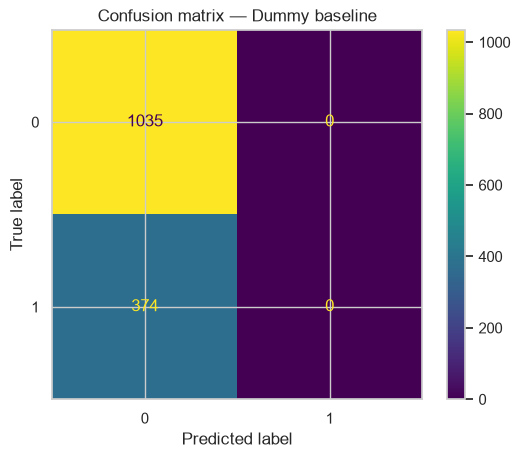

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay

dummy = DummyClassifier(strategy="most_frequent")
dummy_metrics = evaluate(dummy, X_train, y_train, X_test, y_test)
print("Dummy (majority):", dummy_metrics)

ConfusionMatrixDisplay.from_estimator(dummy, X_test, y_test)
plt.title("Confusion matrix — Dummy baseline")
plt.show()

## 5. Baseline 2 — Logistic Regression

Linear model. Two details:
- **Scaling**: LR converges poorly on unscaled features (`MonthlyCharges` ≈ 70 vs `tenure` ≈ 30) → `StandardScaler`
- **Pipeline**: `make_pipeline` bundles scaler + model so we never forget to scale

Logistic Regression: {'Accuracy': 0.807, 'AUC': 0.8416, 'Precision': 0.6584, 'Recall': 0.5668, 'F1': 0.6092}


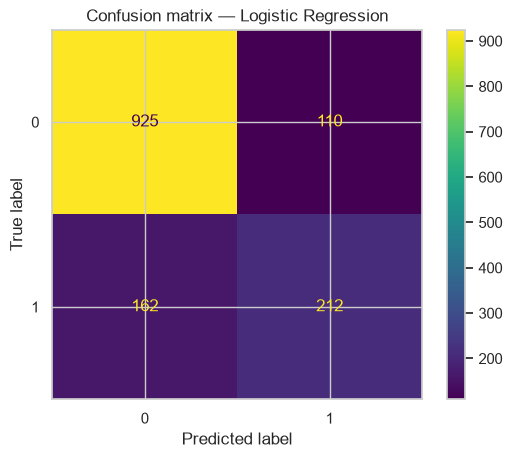

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
lr_metrics = evaluate(lr, X_train, y_train, X_test, y_test)
print("Logistic Regression:", lr_metrics)

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Confusion matrix — Logistic Regression")
plt.show()

## 6. Baseline comparison

In [10]:
# Side-by-side comparison table
results = pd.DataFrame(
    [dummy_metrics, lr_metrics],
    index=["Dummy (majority)", "Logistic Regression"],
)
results

,Accuracy,AUC,Precision,Recall,F1
Dummy (majority),0.7346,0.5000,0.0000,0.0000,0.0000
Logistic Regression,0.8070,0.8416,0.6584,0.5668,0.6092


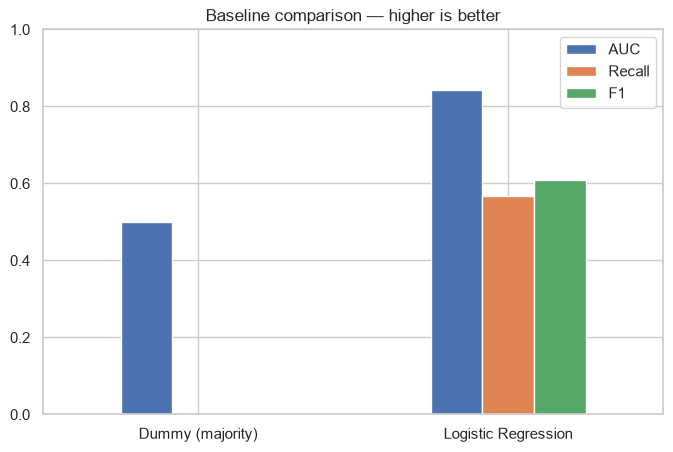

In [11]:
# Visual comparison of the 3 metrics that matter (AUC, Recall, F1)
results[["AUC", "Recall", "F1"]].plot(kind="bar", figsize=(8, 5))
plt.title("Baseline comparison — higher is better")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## 7. Takeaways

- **Dummy** gets ~73.5% accuracy but **AUC ≈ 0.5** (= random). This proves accuracy is a useless metric here.
- **Logistic Regression** should push **AUC ≈ 0.83-0.85** — a big jump with a simple linear model.
- `Contract`, `tenure`, `InternetService` are expected to be the strongest coefficients (consistent with EDA).
- Next: **XGBoost** — the real model, expected AUC ≈ 0.85+.